In [2]:
import pandas as pd
file_path = "/content/drive/MyDrive/audio_features.csv"
df_audio = pd.read_csv(file_path)
print(df_audio.columns)

Index(['Link', 'Label', 'F_0', 'F_1', 'F_2', 'F_3', 'F_4', 'F_5', 'F_6', 'F_7',
       ...
       'F_1014', 'F_1015', 'F_1016', 'F_1017', 'F_1018', 'F_1019', 'F_1020',
       'F_1021', 'F_1022', 'F_1023'],
      dtype='object', length=1026)


In [3]:
file_path = "/content/drive/MyDrive/Embedding /embeddings_with_targets_RNN.csv"
df_video = pd.read_csv(file_path)


In [3]:
print(df_video["Link"].head())
print(f"\nUnique Links: {df_video['Link'].nunique()}")
print(f"Total Rows: {len(df_video)}")

0    /content/drive/MyDrive/1FPS_video/Anger_39_202...
1    /content/drive/MyDrive/1FPS_video/Anger_39_203...
2    /content/drive/MyDrive/1FPS_video/Anger_39_220...
3    /content/drive/MyDrive/1FPS_video/Anger_39_205...
4    /content/drive/MyDrive/1FPS_video/Anger_39_225...
Name: Link, dtype: object

Unique Links: 8575
Total Rows: 8575


In [4]:
print(df_audio["Link"].head())
print(f"\nUnique Links: {df_audio['Link'].nunique()}")
print(f"Total Rows: {len(df_audio)}")

0    /content/audio/Neutral_16_780.199211-786.75961...
1    /content/audio/Anger_2065.964265-2070.58085_Te...
2    /content/audio/Neutral_16_1044.647304-1049.562...
3    /content/audio/Anger_43_2313.639905-2322.90387...
4    /content/audio/Anger_44_294.50469-299.55833_Me...
Name: Link, dtype: object

Unique Links: 8587
Total Rows: 8587


In [4]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder

class FeedForwardNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(FeedForwardNetwork, self).__init__()
        self.ffn = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),  # Add dropout here
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x):
        return self.ffn(x)

class SimpleVATTEmotionPredictor(nn.Module):
    def __init__(self, audio_dim, video_dim, common_space_dim, hidden_dim, num_classes):
        super(SimpleVATTEmotionPredictor, self).__init__()

        self.audio_ffn = FeedForwardNetwork(audio_dim, hidden_dim)

         # Projection heads for common spaces
        self.video_to_va = nn.Sequential(
            nn.Linear(video_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )

        self.audio_to_va = nn.Sequential(
            nn.Linear(hidden_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )

        self.video_to_vt = nn.Sequential(
            nn.Linear(common_space_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )
        self.classifier = nn.Sequential(
            nn.Linear(common_space_dim * 2, hidden_dim),  # Only video and audio
            nn.ReLU(),
            nn.Dropout(0.3),  # Add dropout here
            nn.Linear(hidden_dim, 256),
            nn.Linear(256, num_classes)
        )

    def forward(self, video_features, audio_features):
        audio_hidden = self.audio_ffn(audio_features)

        video_hidden = video_features

         # Project features into common spaces
        z_v_va = self.video_to_va(video_hidden)
        z_a_va = self.audio_to_va(audio_hidden)
        z_v_vt = self.video_to_vt(z_v_va)

         # Concatenate the common space outputs
        combined_embedding = torch.cat([z_v_va, z_a_va], dim=-1)

        emotion_logits = self.classifier(combined_embedding)

        return emotion_logits

In [5]:
import pandas as pd

# 1. Load the files
df_audio = pd.read_csv('/content/drive/MyDrive/audio_features.csv')
df_video = pd.read_csv('/content/drive/MyDrive/Embedding /embeddings_with_targets_RNN.csv')
print(df_audio.shape)
print(df_video.shape)

(8587, 1026)
(8575, 258)


In [13]:
print(df_video[['Link','Label']].head())
print(df_audio[['Link','Label']].head())

                                                Link  Label
0  /content/drive/MyDrive/1FPS_video/Anger_39_202...      0
1  /content/drive/MyDrive/1FPS_video/Anger_39_203...      0
2  /content/drive/MyDrive/1FPS_video/Anger_39_220...      0
3  /content/drive/MyDrive/1FPS_video/Anger_39_205...      0
4  /content/drive/MyDrive/1FPS_video/Anger_39_225...      0
                                                Link    Label
0  /content/audio/Neutral_16_780.199211-786.75961...  Neutral
1  /content/audio/Anger_2065.964265-2070.58085_Te...    Anger
2  /content/audio/Neutral_16_1044.647304-1049.562...  Neutral
3  /content/audio/Anger_43_2313.639905-2322.90387...    Anger
4  /content/audio/Anger_44_294.50469-299.55833_Me...    Anger


In [5]:
import pandas as pd
import os
import numpy as np

# 1. Load the files
df_audio = pd.read_csv('/content/drive/MyDrive/audio_features.csv')
df_video = pd.read_csv('/content/drive/MyDrive/Embedding /embeddings_with_targets_RNN.csv')

def get_clean_name(path):
    # 1. Get the filename with extension
    filename = os.path.basename(str(path))

    # 2. Separate the name from the LAST extension
    name_without_extension, extension = os.path.splitext(filename)

    return name_without_extension

# Apply cleaning to create a common key
df_audio['Clean_Link'] = df_audio['Link'].apply(get_clean_name)
df_video['Clean_Link'] = df_video['Link'].apply(get_clean_name)
df_video.rename(columns={'Target': 'Label'}, inplace=True)

# 2. INNER JOIN on the CLEANED key
df_merged = pd.merge(df_audio, df_video, on='Clean_Link', how='inner')

print(f"Successfully merged {len(df_merged)} samples.")



Successfully merged 8575 samples.


In [22]:
print(df_merged[['Link_x', 'Label_x', 'Link_y', 'Label_y']].head(10))

                                               Link_x  Label_x  \
0   /content/audio/Neutral_16_780.199211-786.75961...  Neutral   
1   /content/audio/Anger_2065.964265-2070.58085_Te...    Anger   
2   /content/audio/Neutral_16_1044.647304-1049.562...  Neutral   
3   /content/audio/Anger_43_2313.639905-2322.90387...    Anger   
4   /content/audio/Anger_44_294.50469-299.55833_Me...    Anger   
5   /content/audio/Anger_22_7.451325-15.454099_Ang...    Anger   
7   /content/audio/Neutral_7_298.971783-304.660334...  Neutral   
8   /content/audio/Sad_767_12.666055-17.757074_Sad...      Sad   
9   /content/audio/Love_322_2407.989876-2420.84441...     Love   
10  /content/audio/Happy_123_1334.642768-1338.9268...    Happy   

                                               Link_y  Label_y  
0   /content/drive/MyDrive/1FPS_video/Neutral_16_7...        3  
1   /content/drive/MyDrive/1FPS_video/Anger_2065.9...        0  
2   /content/drive/MyDrive/1FPS_video/Neutral_16_1...        3  
3   /content/

In [6]:
label_map = {
    'Anger': 0,
    'Happy': 1,
    'Love': 2,
    'Neutral': 3,
    'Sad': 4
}

df_merged['Label_x_encoded'] = df_merged['Label_x'].map(label_map)

In [9]:
df_merged['match'] = df_merged['Label_x_encoded'] == df_merged['Label_y']

print(df_merged['match'].value_counts())

match
True    8531
Name: count, dtype: int64


In [8]:
df_merged = df_merged[df_merged['match'] == True]

In [26]:
print(df_merged.columns)

Index(['Link_x', 'Label_x', 'F_0', 'F_1', 'F_2', 'F_3', 'F_4', 'F_5', 'F_6',
       'F_7',
       ...
       '250', '251', '252', '253', '254', '255', 'Label_y', 'Link_y',
       'Label_x_encoded', 'match'],
      dtype='object', length=1287)


In [10]:
# Audio features (F_ columns)
audio_cols = [col for col in df_merged.columns if col.startswith('F_')]

# Video features (0–255)
video_cols = [str(i) for i in range(256)]

# Extract data
audio_features = df_merged[audio_cols].values
video_features = df_merged[video_cols].values

# Labels
labels = df_merged['Label_x_encoded'].values


In [11]:
from sklearn.preprocessing import StandardScaler

# --- 1. Scaling  ---
scaler_audio = StandardScaler()
scaler_text = StandardScaler()

# Scale Features
audio_features_scaled = scaler_audio.fit_transform(audio_features)
video_features_scaled = scaler_text.fit_transform(video_features)

In [12]:
audio_tensor = torch.tensor(audio_features_scaled, dtype=torch.float32)
video_tensor = torch.tensor(video_features_scaled, dtype=torch.float32)
label_tensor = torch.tensor(labels, dtype=torch.long)

In [13]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(audio_tensor, video_tensor, label_tensor)

# 80-20 train-test split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [14]:
audio_dim = audio_tensor.shape[1]
video_dim = video_tensor.shape[1]

model = SimpleVATTEmotionPredictor(
    audio_dim=audio_dim,
    video_dim=video_dim,
    common_space_dim=128,
    hidden_dim=256,
    num_classes=len(set(labels))
)

In [15]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 50

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for v, a, y in train_loader:
    v, a, y = v.to(device), a.to(device), y.to(device)

    optimizer.zero_grad()

    outputs = model(a, v)
    loss = criterion(outputs, y)

    loss.backward()
    optimizer.step()

    total_loss += loss.item()
  avg_loss = total_loss / len(train_loader)
  if (epoch + 1) % 5 == 0:
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")



Epoch 5, Loss: 0.3737
Epoch 10, Loss: 0.3376
Epoch 15, Loss: 0.2854
Epoch 20, Loss: 0.2943
Epoch 25, Loss: 0.2685
Epoch 30, Loss: 0.2368
Epoch 35, Loss: 0.2247
Epoch 40, Loss: 0.2140
Epoch 45, Loss: 0.1937
Epoch 50, Loss: 0.2007


In [23]:
correct = 0
total = 0

with torch.no_grad():
    for v, a, y in test_loader:
        v, a, y = v.to(device), a.to(device), y.to(device)
        outputs = model(a, v)
        _, predicted = torch.max(outputs, 1)

        total += y.size(0)
        correct += (predicted == y).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 63.33%


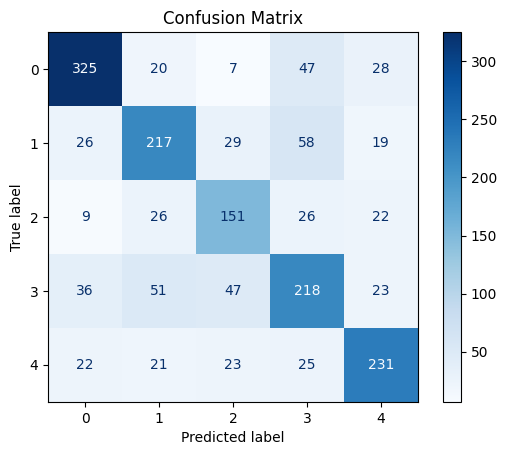

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for v, a, y in test_loader:
        v, a = v.to(device), a.to(device)
        outputs = model(a, v)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()